### Step 1: Import Required Libraries
We import **pandas** for data manipulation and **numpy** for numerical operations.

In [9]:
# Import required libraries
import pandas as pd
import numpy as np

### Step 2: Load the Dataset
We load the Steel Industry dataset and inspect the first 5 rows to verify the data loaded correctly.

In [10]:
# Load the dataset and display the first 5 rows
df = pd.read_excel('/content/Week 2 (DataSet).xlsx')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### Step 3: Explore Dataset Structure
We check the total number of rows, columns, and data types of each feature in the dataset.

In [11]:
# Check the number of rows and columns
print("Dataset Shape (Rows, Columns):", df.shape)

# Display the column names and data types
df.info()

Dataset Shape (Rows, Columns): (35040, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             3

### Step 4: Check for Missing Values
We inspect the dataset to check if there are any missing (null) values that need to be handled.

In [12]:
# Check for missing (null) values in all columns
df.isnull().sum()

,0
date,0
Usage_kWh,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0
CO2(tCO2),0
Lagging_Current_Power_Factor,0
Leading_Current_Power_Factor,0
NSM,0
WeekStatus,0
Day_of_week,0


### Step 5: Statistical Summary
We generate statistical details like mean, standard deviation, minimum, and maximum values for all numerical features to understand their distribution.

In [13]:
# Generate descriptive statistics for numerical columns
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


### Step 6: Feature Selection for PCA
We select only the numerical features and drop non-numerical columns like dates and categorical variables because PCA only works on continuous numerical data.

In [14]:
# Select only numerical columns for PCA (excluding the date and categorical columns)
numerical_cols = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM'
]

# Create a new dataframe with only numerical features
df_numerical = df[numerical_cols]

# Verify the numerical dataframe shape and columns
df_numerical.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
0,3.17,2.95,0.0,0.0,73.21,100.0,900
1,4.00,4.46,0.0,0.0,66.77,100.0,1800
2,3.24,3.28,0.0,0.0,70.28,100.0,2700
3,3.31,3.56,0.0,0.0,68.09,100.0,3600
4,3.82,4.50,0.0,0.0,64.72,100.0,4500


### Step 7: Data Standardization
We scale the numerical features using StandardScaler so that all features are on the same scale (mean = 0, variance = 1), which is a prerequisite for PCA.

In [15]:
# Import StandardScaler from sklearn
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the numerical data
scaled_data = scaler.fit_transform(df_numerical)

# Convert scaled data back to a dataframe to verify
df_scaled = pd.DataFrame(scaled_data, columns=df_numerical.columns)
df_scaled.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
0,-0.724105,-0.618516,-0.521385,-0.71355,-0.389410,0.513268,-1.678015
1,-0.699287,-0.525911,-0.521385,-0.71355,-0.729772,0.513268,-1.641929
2,-0.722012,-0.598278,-0.521385,-0.71355,-0.544264,0.513268,-1.605843
3,-0.719919,-0.581106,-0.521385,-0.71355,-0.660009,0.513268,-1.569756
4,-0.704669,-0.523458,-0.521385,-0.71355,-0.838117,0.513268,-1.533670


### Step 8: Apply PCA
We apply Principal Component Analysis (PCA) to find the principal components and analyze the explained variance ratio of each component.

In [16]:
# Import PCA from sklearn
from sklearn.decomposition import PCA

# Initialize PCA with all 7 components (since we have 7 numerical columns)
pca = PCA(n_components=7)

# Fit PCA on the scaled data
pca.fit(df_scaled)

# Get the explained variance ratio for each component
explained_variance = pca.explained_variance_ratio_

# Print the variance explained by each component
for i, var in enumerate(explained_variance):
    print(f"Principal Component {i+1}: {var:.4f} ({var*100:.2f}%)")

Principal Component 1: 0.4854 (48.54%)
Principal Component 2: 0.3690 (36.90%)
Principal Component 3: 0.0821 (8.21%)
Principal Component 4: 0.0433 (4.33%)
Principal Component 5: 0.0117 (1.17%)
Principal Component 6: 0.0069 (0.69%)
Principal Component 7: 0.0016 (0.16%)


### Step 9: Plot Cumulative Explained Variance
We plot the cumulative explained variance to visually determine the optimal number of principal components to keep (using the Elbow/Scree plot method).

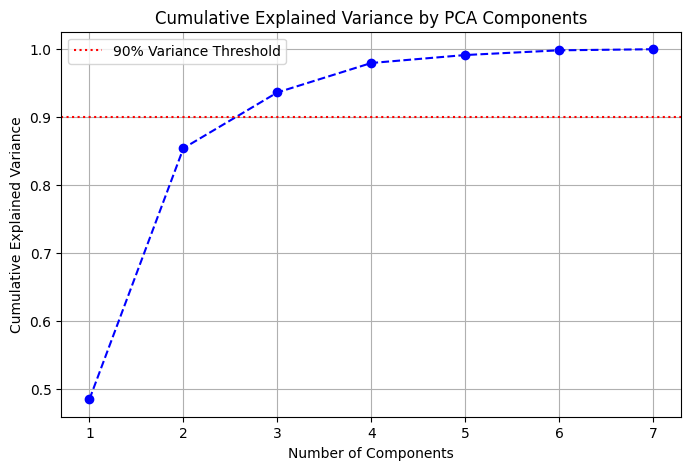

In [17]:
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.legend()
plt.show()

### Step 10: Apply PCA with 3 Optimal Components
Based on the cumulative variance plot, we select $k = 3$ components to retain over 93% of the original information while significantly reducing dataset dimensionality.

In [18]:
# Initialize PCA with 3 optimal components
pca_3 = PCA(n_components=3)

# Fit and transform the scaled data
pca_features = pca_3.fit_transform(df_scaled)

# Create a new DataFrame with the 3 Principal Components
df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2', 'PC3'])

# Verify the new reduced dataset
df_pca.head()

,PC1,PC2,PC3
0,-0.691277,-1.824022,-0.786852
1,-0.644980,-1.983060,-0.730667
2,-0.684878,-1.874780,-0.707725
3,-0.679064,-1.920715,-0.664398
4,-0.648924,-1.994406,-0.622464


### Step 11: Prepare Features and Target, and Split the Dataset
We define our features (the 3 Principal Components) and target variable (`Load_Type`), then split the dataset into 80% training and 20% testing sets.

In [19]:
from sklearn.model_selection import train_test_split

# Features are our PCA components
X = df_pca

# Target variable is 'Load_Type' from original dataframe
y = df['Load_Type']

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (28032, 3)
Testing set shape: (7008, 3)


### Step 12: Train and Compare Baseline Models with PCA
We train and evaluate the models selected during Week 2 (Logistic Regression, Ridge Classifier, Decision Tree, and Random Forest) using our 3 Principal Components to determine the best model for dashboard deployment.

In [21]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the exact models from Week 2 (configured for Classification)
baseline_models = {
    "Logistic Regression (Linear)": LogisticRegression(max_iter=1000, random_state=42),
    "Ridge Classifier": RidgeClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (Champion)": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Dictionary to store accuracies
pca_accuracies = {}

# 3. Train and evaluate each model on PCA features
print("--- Training Baseline Models with 3 PCA Components ---")
for name, model in baseline_models.items():
    # Train model
    model.fit(X_train, y_train)
    # Predict
    predictions = model.predict(X_test)
    # Calculate accuracy
    acc = accuracy_score(y_test, predictions)
    pca_accuracies[name] = acc
    print(f"{name} trained successfully.")

# 4. Print Comparison Results
print("\n--- Model Accuracy Comparison on PCA Data ---")
for name, acc in pca_accuracies.items():
    print(f"{name}: {acc*100:.2f}%")

# Find the best model
best_model_name = max(pca_accuracies, key=pca_accuracies.get)
print(f"\n⭐ Best Performing Model: {best_model_name} with {pca_accuracies[best_model_name]*100:.2f}% accuracy!")

--- Training Baseline Models with 3 PCA Components ---
Logistic Regression (Linear) trained successfully.
Ridge Classifier trained successfully.
Decision Tree trained successfully.
Random Forest (Champion) trained successfully.

--- Model Accuracy Comparison on PCA Data ---
Logistic Regression (Linear): 70.28%
Ridge Classifier: 68.07%
Decision Tree: 84.10%
Random Forest (Champion): 86.33%

⭐ Best Performing Model: Random Forest (Champion) with 86.33% accuracy!


### Step 13: Save the Best Performing Model
Since Random Forest emerged as the champion model with the highest accuracy, we export/save this trained model using `joblib` so it can be directly deployed in our FastAPI dashboard.

In [22]:
import joblib

# Get the actual trained Random Forest model from our dictionary
best_rf_model = baseline_models["Random Forest (Champion)"]

# Save the trained model to a file
joblib.dump(best_rf_model, 'best_random_forest_model.pkl')

# Save the scaler as well (since the dashboard will need to scale new inputs the exact same way)
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully as 'best_random_forest_model.pkl' and 'scaler.pkl'!")

Model and Scaler saved successfully as 'best_random_forest_model.pkl' and 'scaler.pkl'!


In [24]:
# Save the 3-component PCA transformer
import joblib
joblib.dump(pca_3, 'pca_transformer.pkl')
print("PCA Transformer saved successfully as 'pca_transformer.pkl'!")

PCA Transformer saved successfully as 'pca_transformer.pkl'!


### Step 14: Creating the FastAPI Application Script
We write a Python script that loads our saved PCA-based Random Forest model, scaler, and PCA transformer, and exposes a POST API endpoint for predicting the energy `Load_Type` based on real-time inputs.

In [25]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="Steel Industry Load Type Predictor", description="API for predicting load type using PCA and Random Forest Classifier")

# 1. Load all saved objects
model = joblib.load('best_random_forest_model.pkl')
scaler = joblib.load('scaler.pkl')
pca = joblib.load('pca_transformer.pkl')

# 2. Define input format (the 7 raw features)
class PredictionInput(BaseModel):
    Usage_kWh: float
    Lagging_Current_Reactive_Power_kVarh: float
    Leading_Current_Reactive_Power_kVarh: float
    CO2_tCO2: float
    Lagging_Current_Power_Factor: float
    Leading_Current_Power_Factor: float
    NSM: float

# 3. Base URL (Home Screen of API)
@app.get("/")
def home():
    return {"message": "Welcome to the Steel Industry Load Type Prediction Dashboard API!"}

# 4. Prediction URL
@app.post("/predict")
def predict_load_type(data: PredictionInput):
    # Convert input to numpy array
    raw_features = np.array([[
        data.Usage_kWh,
        data.Lagging_Current_Reactive_Power_kVarh,
        data.Leading_Current_Reactive_Power_kVarh,
        data.CO2_tCO2,
        data.Lagging_Current_Power_Factor,
        data.Leading_Current_Power_Factor,
        data.NSM
    ]])

    # Scale and apply PCA
    scaled_features = scaler.transform(raw_features)
    pca_features = pca.transform(scaled_features)

    # Predict using the Champion Random Forest model
    prediction = model.predict(pca_features)

    return {
        "prediction": prediction[0],
        "features_pca": {
            "PC1": float(pca_features[0][0]),
            "PC2": float(pca_features[0][1]),
            "PC3": float(pca_features[0][2])
        }
    }

Writing app.py


### Step 15: Install Server Requirements & Run FastAPI
We install `uvicorn`, `nest_asyncio`, and `pyngrok` to run the FastAPI server directly inside our Google Colab environment and expose it to a public URL.

In [26]:
# Install uvicorn and nest_asyncio to run the server in Jupyter
!pip install uvicorn nest_asyncio pyngrok -q

import nest_asyncio
import uvicorn
import multiprocessing

# This allows uvicorn to run inside the Colab notebook without blocking the kernel
nest_asyncio.apply()
print("Requirements installed and nest_asyncio applied successfully!")

Requirements installed and nest_asyncio applied successfully!


In [28]:
import joblib

# Purani heavy model file ko load karein
model = joblib.load('best_random_forest_model.pkl')

# Isko high compression (compress=3) ke sath dubara save karein
joblib.dump(model, 'best_random_forest_model.pkl', compress=3)

print("File successfully compressed!")

File successfully compressed!


### Step 16: Launch FastAPI Server with Localtunnel
We start our Uvicorn server in the background and use `localtunnel` to create a secure public URL so we can access and test our API.

In [ ]:
import subprocess
import time

# 1. Start Uvicorn server in the background on port 8000
print("Starting Uvicorn server...")
server_process = subprocess.Popen(["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"])

# Give the server 3 seconds to spin up
time.sleep(3)

# 2. Get the public IP of your Colab instance (needed as a password/tunnel-password for localtunnel)
print("\n--- Localtunnel Password (Your Colab Public IP) ---")
!curl ipv4.icanhazip.com
print("--------------------------------------------------\n")

# 3. Start localtunnel on port 8000 in the background (using -y to bypass the prompt)
print("Starting localtunnel to generate public URL...")
tunnel_process = subprocess.Popen(["npx", "-y", "localtunnel", "--port", "8000"], stdout=subprocess.PIPE)

# Give localtunnel 5 seconds to generate the URL
time.sleep(5)

# 4. Extract and print the generated URL
print("Generating link...")
!npx -y localtunnel --port 8000

Starting Uvicorn server...

--- Localtunnel Password (Your Colab Public IP) ---
136.107.184.107
--------------------------------------------------

Starting localtunnel to generate public URL...
Generating link...
⠙⠹⠸⠼⠴⠦your url is: https://kind-cloths-send.loca.lt
